In [18]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [6]:
test_path = '../data/raw/dogs_vs_cats/test'
train_path = '../data/raw/dogs_vs_cats/train'

Separamos imagenes de gatos de las de perros

In [2]:
cat_images = '../data/raw/dogs_vs_cats/test/cats'
dog_images = '../data/raw/dogs_vs_cats/test/dogs'

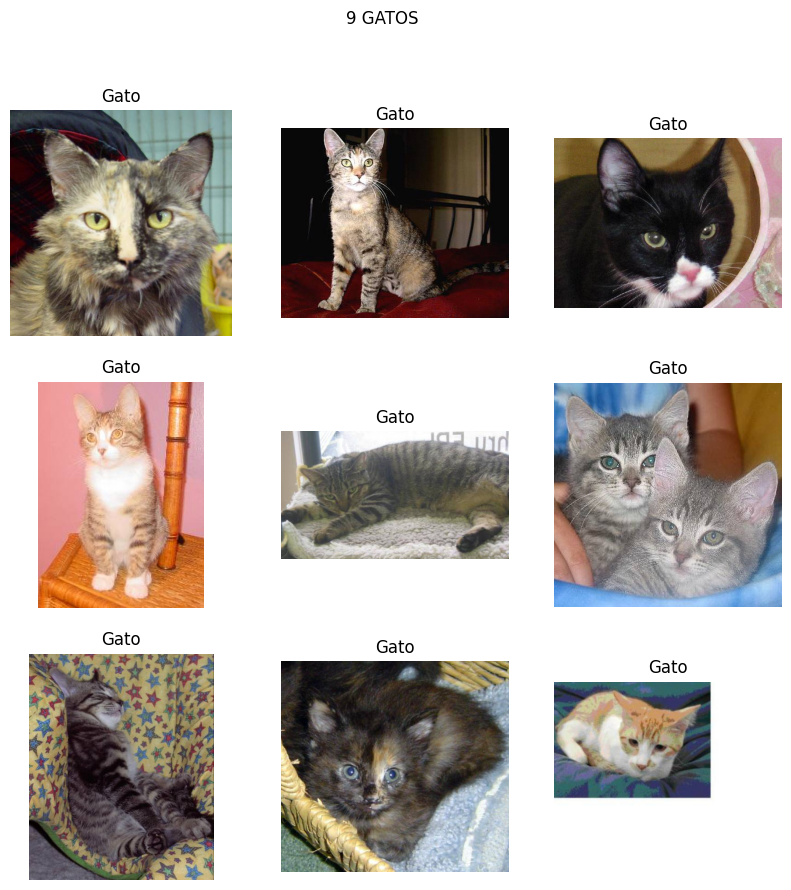

In [24]:
cat_files = os.listdir(cat_images)[:9]
plt.figure(figsize=(10,10))
for i, fname in enumerate(cat_files):
    img = mpimg.imread(os.path.join(cat_images, fname))
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Gato')
plt.suptitle('9 GATOS')
plt.show()

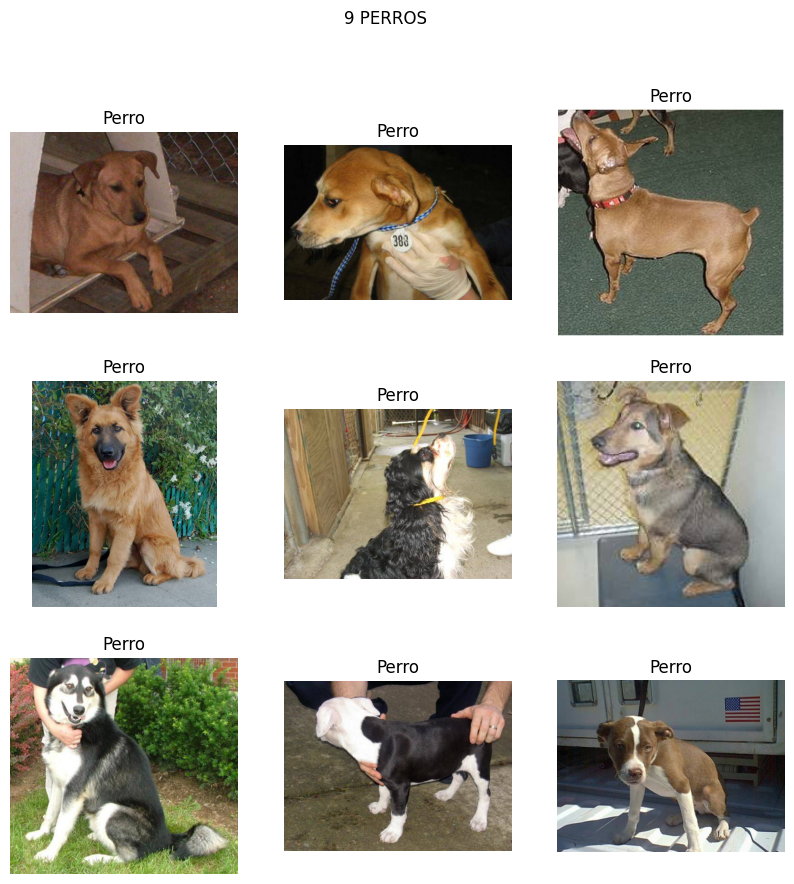

In [25]:
dog_files = os.listdir(dog_images)[:9]
plt.figure(figsize=(10,10))
for i, fname in enumerate(dog_files):
    img = mpimg.imread(os.path.join(dog_images, fname))
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Perro')
plt.suptitle('9 PERROS')
plt.show()

In [4]:
trdata_gen = ImageDataGenerator(rescale=1./255)
tsdata_gen = ImageDataGenerator(rescale=1./255)

In [13]:
trdata = trdata_gen.flow_from_directory(train_path,
                                        target_size=(128,128),
                                        batch_size=32,
                                        class_mode='categorical',
                                        shuffle=True)

tsdata = tsdata_gen.flow_from_directory(test_path,
                                        target_size=(128,128),
                                        batch_size=32,
                                        class_mode='categorical',
                                        shuffle=False)


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [ ]:
model = Sequential()
model.add(Input(shape=(128, 128, 3)))

model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # porque tu salida tiene 2 neuronas y activación softmax
    metrics=['accuracy']
)

history = model.fit(
    trdata,
    epochs=3,
    validation_data=tsdata
)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 640s 1s/step - accuracy: 0.5917 - loss: 0.6609 - val_accuracy: 0.7412 - val_loss: 0.5297
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 183s 292ms/step - accuracy: 0.7370 - loss: 0.5305 - val_accuracy: 0.7894 - val_loss: 0.4558
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 367ms/step - accuracy: 0.7837 - loss: 0.4620 - val_accuracy: 0.7938 - val_loss: 0.4431


In [ ]:
loss, accuracy = model.evaluate(tsdata)
loss, accuracy

157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 209ms/step - accuracy: 0.7713 - loss: 0.4667
Pérdida en test: 0.4431
Precisión en test: 0.7938


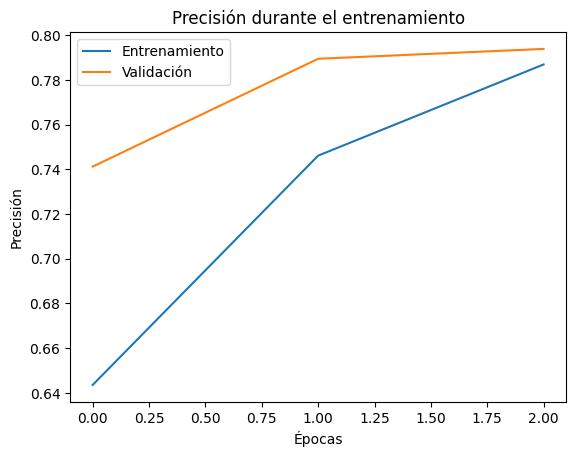

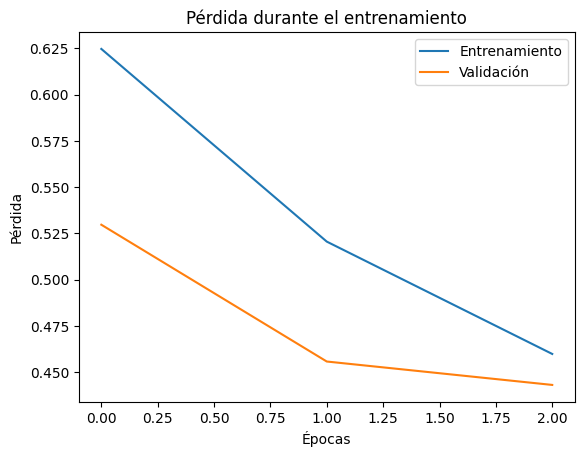

In [ ]:

plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()


plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Vamos a usar earlystopping y modelcheckpoint para optimizar

In [19]:
checkpoint = ModelCheckpoint(
    'mejor_modelo.h5',      
    monitor='val_accuracy',  
    verbose=1,
    save_best_only=True,     
    mode='max'               
)


earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,              
    verbose=1,
    restore_best_weights=True  
)

In [21]:
history = model.fit(
    trdata,
    epochs=9,
    validation_data=tsdata,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.8102 - loss: 0.4213
Epoch 1: val_accuracy improved from -inf to 0.82280, saving model to mejor_modelo.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 237s 378ms/step - accuracy: 0.8102 - loss: 0.4213 - val_accuracy: 0.8228 - val_loss: 0.4080
Epoch 2/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8332 - loss: 0.3791
Epoch 2: val_accuracy improved from 0.82280 to 0.82300, saving model to mejor_modelo.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 228s 365ms/step - accuracy: 0.8332 - loss: 0.3791 - val_accuracy: 0.8230 - val_loss: 0.4179
Epoch 3/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.8468 - loss: 0.3459
Epoch 3: val_accuracy improved from 0.82300 to 0.83300, saving model to mejor_modelo.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 248s 396ms/step - accuracy: 0.8468 - loss: 0.3459 - val_accuracy: 0.8330 - val_loss: 0.3913
Epoch 4/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.8696 - loss: 0.3021
Epoch 4: val_accuracy did not improve from 0.83300
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 330ms/step - accuracy: 0.8696 - loss: 0.3021 - val_accuracy: 0.8188 - val_loss: 0.4275
Epoch 5/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.8812 - loss: 0.2721
Epoch 5: val_accuracy improved from 0.83300 to 0.84480, saving model to mejor_modelo.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 251s 402ms/step - accuracy: 0.8812 - loss: 0.2721 - val_accuracy: 0.8448 - val_loss: 0.3802
Epoch 6/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.8968 - loss: 0.2396
Epoch 6: val_accuracy improved from 0.84480 to 0.85060, saving model to mejor_modelo.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 386s 618ms/step - accuracy: 0.8968 - loss: 0.2396 - val_accuracy: 0.8506 - val_loss: 0.3893
Epoch 7/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9081 - loss: 0.2082
Epoch 7: val_accuracy did not improve from 0.85060
625/625 ━━━━━━━━━━━━━━━━━━━━ 310s 495ms/step - accuracy: 0.9080 - loss: 0.2082 - val_accuracy: 0.8478 - val_loss: 0.3944
Epoch 8/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9206 - loss: 0.1835
Epoch 8: val_accuracy did not improve from 0.85060
625/625 ━━━━━━━━━━━━━━━━━━━━ 313s 477ms/step - accuracy: 0.9206 - loss: 0.1835 - val_accuracy: 0.8404 - val_loss: 0.4580
Epoch 9/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.9319 - loss: 0.1636
Epoch 9: val_accuracy did not improve from 0.85060
625/625 ━━━━━━━━━━━━━━━━━━━━ 227s 363ms/step - accuracy: 0.9319 - loss: 0.1636 - val_accuracy: 0.8470 - val_loss: 0.4452
Restoring model weights from the end of the best epoch: 6.


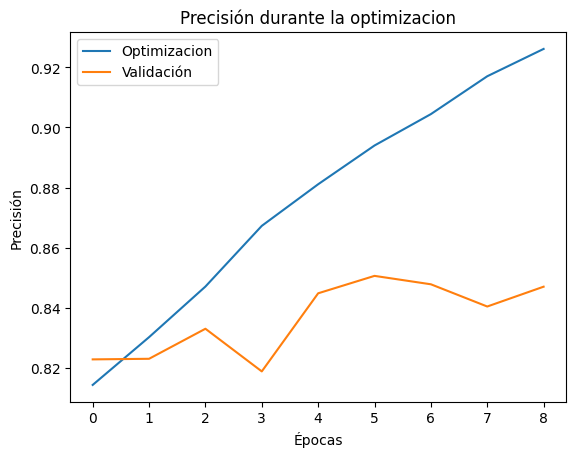

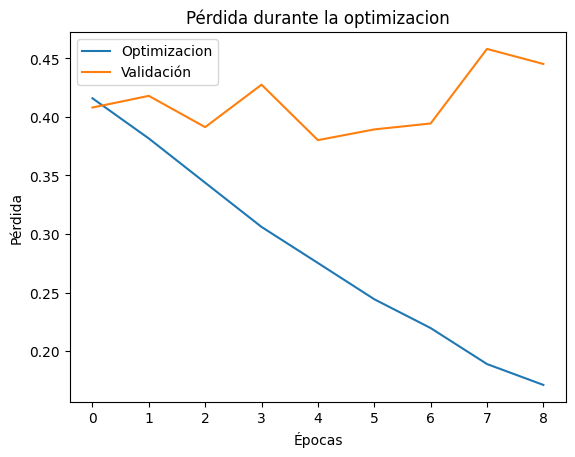

In [25]:
plt.plot(history.history['accuracy'], label='Optimizacion')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión durante la optimizacion')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()


plt.plot(history.history['loss'], label='Optimizacion')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante la optimizacion')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

In [ ]:
model.save('modelo_perros_y_gatos.h5')